<a href="https://colab.research.google.com/github/ChetanTiwari195/NewYorkTaxiEDA_DS_CT/blob/main/ETL_Crash_Analysis_Chetan_Tiwari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Load the processed dataset as CSV files in S3 bucket.</br>
    4.2. Identify the top 5 counties with the highest number of collisions.</br>
    4.3. Identify the month with the highest number of collisions.</br>
    4.4. Determine the most common weather condition during collisions.</br>
    4.5. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.6. Find the most dangerous time of day for collisions.</br>
    4.7. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.8. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Install Required Libraries

In [2]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [3]:
# Import the necessary libraries
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date, when, count, isnan, mean, median, mode
from pyspark.sql.types import NumericType, StringType
import os

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [4]:
# Write code to load the data and check the schema
spark = (SparkSession
    .builder
    .appName("TrafficCollisionAnalysis")
    .getOrCreate()
)

print(spark.version)


4.0.2


In [5]:
# Define the path to the directory containing the CSV files
DB_PATH = '/content/drive/MyDrive/ColabNotebooks/crashDataAnalysis'

collisions_df = spark.read.csv(f"{DB_PATH}/sample_collisions.csv", header=True, inferSchema=True)
parties_df = spark.read.csv(f"{DB_PATH}/sample_parties.csv", header=True, inferSchema=True)
victims_df = spark.read.csv(f"{DB_PATH}/sample_victims.csv", header=True, inferSchema=True)
ids_df = spark.read.csv(f"{DB_PATH}/sample_case_ids.csv", header=True, inferSchema=True)

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [6]:
#Display Schema & Sample Data
print("Schema for collisions_df:")
collisions_df.printSchema()
print("Sample data for collisions_df:")
collisions_df.show(5, truncate=False)

print("\nSchema for parties_df:")
parties_df.printSchema()
print("\nSample data for parties_df:")
parties_df.show(5, truncate=False)

print("\nSchema for victims_df:")
victims_df.printSchema()
print("\nSample data for parties_df:")
victims_df.show(5, truncate=False)

print("\nSchema for ids_df:")
ids_df.printSchema()
print("\nSample data for ids_df:")
ids_df.show(5, truncate=False)

Schema for collisions_df:
root
 |-- case_id: double (nullable = true)
 |-- jurisdiction: double (nullable = true)
 |-- officer_id: string (nullable = true)
 |-- reporting_district: string (nullable = true)
 |-- chp_shift: string (nullable = true)
 |-- population: string (nullable = true)
 |-- county_city_location: integer (nullable = true)
 |-- county_location: string (nullable = true)
 |-- special_condition: double (nullable = true)
 |-- beat_type: string (nullable = true)
 |-- chp_beat_type: string (nullable = true)
 |-- chp_beat_class: string (nullable = true)
 |-- beat_number: string (nullable = true)
 |-- primary_road: string (nullable = true)
 |-- secondary_road: string (nullable = true)
 |-- distance: double (nullable = true)
 |-- direction: string (nullable = true)
 |-- intersection: double (nullable = true)
 |-- weather_1: string (nullable = true)
 |-- state_highway_indicator: double (nullable = true)
 |-- caltrans_county: string (nullable = true)
 |-- caltrans_district: doubl

##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [7]:
#Check for Missing Values
print("Collision Table")
collisions_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in collisions_df.columns
]).show()

print("Parties Table")
parties_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in parties_df.columns
]).show()

print("Victims Table")
victims_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in victims_df.columns
]).show()

print("Ids Table")
ids_df.select([
    sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in ids_df.columns
]).show()

Collision Table
+-------+------------+----------+------------------+---------+----------+--------------------+---------------+-----------------+---------+-------------+--------------+-----------+------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+-----------+-----------------+---------------------------+-----------------+------------+----------------+--------+--------------+-------------+--------------------+-----------------+--------------------+---------------+--------------------+-------------------------------+-------------------------+-------------------+--------------------------+------------------------------+-----------------------+------------------------+----------------------+-------------------

In [8]:
threshold = 0.90

tables_list = [
    ("collisions_df", collisions_df),
    ("parties_df", parties_df),
    ("victims_df", victims_df),
    ("ids_df", ids_df)
]

updated_dfs = {}

for name, df in tables_list:

    total_rows = df.count()

    if total_rows == 0:
        continue

    # Missing counts
    missing_counts = df.select([
        sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]).collect()[0].asDict()

    print(f"\n{name}")

    # Make a mutable copy for filtering
    current_df = df

    # Remove rows for columns having <7% missing values
    for c, cnt in missing_counts.items():

        missing_percent = cnt / total_rows

        print(f"{c}: {missing_percent*100:.2f}% missing")

        if 0 < missing_percent < 0.07:

            before = current_df.count()

            current_df = current_df.filter(col(c).isNotNull())

            after = current_df.count()

            print(f"Dropped null rows from '{c}' | Removed {before-after} rows")

    # Drop sparse columns
    sparse_cols = [
        c for c, cnt in missing_counts.items()
        if cnt / total_rows > threshold
    ]

    if sparse_cols:
        current_df = current_df.drop(*sparse_cols)

        print(f"Dropped sparse columns: {sparse_cols}")

    else:
        print("No columns with >90% missing values")

    updated_dfs[name] = current_df

# Reassign the global DataFrames
collisions_df = updated_dfs['collisions_df']
parties_df = updated_dfs['parties_df']
victims_df = updated_dfs['victims_df']
ids_df = updated_dfs['ids_df']


collisions_df
case_id: 0.00% missing
jurisdiction: 0.12% missing
Dropped null rows from 'jurisdiction' | Removed 1158 rows
officer_id: 0.24% missing
Dropped null rows from 'officer_id' | Removed 2263 rows
reporting_district: 59.06% missing
chp_shift: 0.00% missing
population: 0.02% missing
Dropped null rows from 'population' | Removed 162 rows
county_city_location: 0.00% missing
county_location: 0.00% missing
special_condition: 5.53% missing
Dropped null rows from 'special_condition' | Removed 51730 rows
beat_type: 0.00% missing
chp_beat_type: 0.00% missing
chp_beat_class: 0.03% missing
Dropped null rows from 'chp_beat_class' | Removed 274 rows
beat_number: 8.63% missing
primary_road: 0.00% missing
Dropped null rows from 'primary_road' | Removed 9 rows
secondary_road: 0.00% missing
Dropped null rows from 'secondary_road' | Removed 2 rows
distance: 0.00% missing
direction: 24.86% missing
intersection: 1.01% missing
Dropped null rows from 'intersection' | Removed 9431 rows
weather_1: 0.

In [9]:
#Convert Data Types
# all the data types are already correct no need for any changes

In [10]:
#Handle Missing Values
# sample dataframe of pandas to visualize and clean pyspark data
# generate smaller pandas samples from pyspark dfs

collisions_pd = collisions_df.sample(0.15, seed=42).toPandas()
parties_pd = parties_df.sample(0.15, seed=42).toPandas()
victims_pd = victims_df.sample(0.15, seed=42).toPandas()

In [11]:
missing_prop_collision = collisions_pd.isnull().mean()*100
missing_prop_collision[missing_prop_collision > 0].sort_values(ascending=False)

,0
side_of_highway,72.503950
caltrans_county,72.503091
location_type,72.503091
postmile,72.484201
state_route,72.484201
caltrans_district,72.484201
latitude,68.142087
longitude,68.142087
reporting_district,64.142568
pcf_violation_subsection,61.484235


In [12]:
# setting caltrans county as unknown for na values
collisions_df = collisions_df.fillna('unknown', subset=['caltrans_county'])

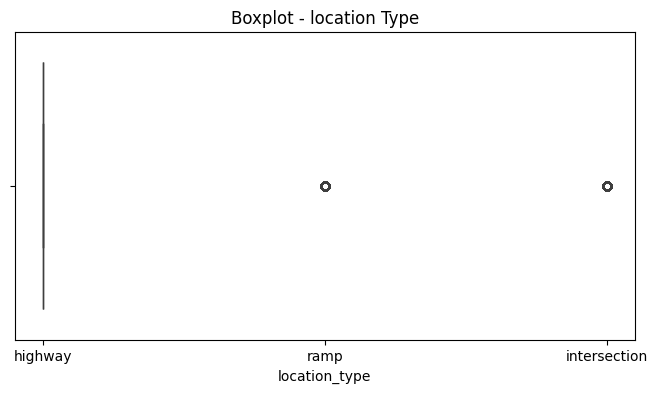

In [13]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['location_type'])
plt.title('Boxplot - location Type')
plt.show()

In [14]:
collisions_pd['location_type'] = collisions_pd['location_type'].fillna('unknown')

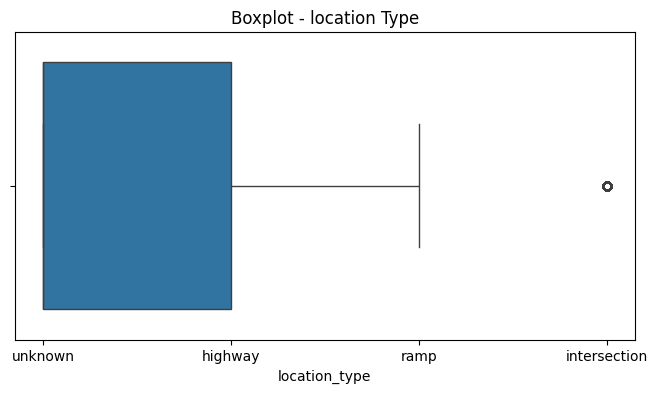

In [15]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['location_type'])
plt.title('Boxplot - location Type')
plt.show()

In [16]:
collisions_df = collisions_df.fillna('unknown', subset=['location_type'])

In [17]:
# filled na with unknown as filling it with mode value can skew the results as we are not sure 72% mode accidents happened in highways only

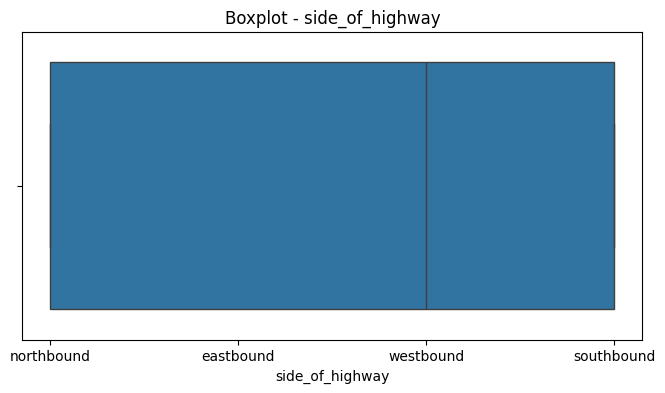

In [18]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['side_of_highway'])
plt.title('Boxplot - side_of_highway')
plt.show()

In [19]:
collisions_pd['side_of_highway'] = collisions_pd['side_of_highway'].fillna('unknown')

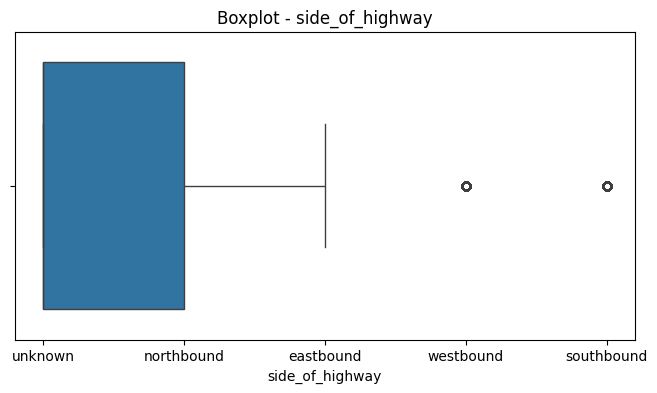

In [20]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['side_of_highway'])
plt.title('Boxplot - side_of_highway')
plt.show()

In [21]:
collisions_df = collisions_df.fillna('unknown', subset=['side_of_highway'])

In [22]:
# filling latitude and longitude values as 0, o as we are not sure f correct long and lat

In [23]:
collisions_df = collisions_df.fillna(0, subset=['latitude', 'longitude'])

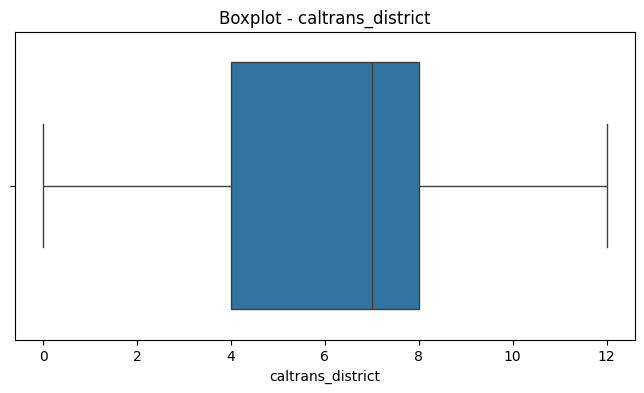

In [24]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['caltrans_district'])
plt.title('Boxplot - caltrans_district')
plt.show()

In [25]:
collisions_pd['caltrans_district'].mean()
collisions_df = collisions_df.fillna(collisions_pd['caltrans_district'].mean(), subset=['caltrans_district'])

In [26]:
# filled collision district as the mean value of the this column as any other value would have skewed the data

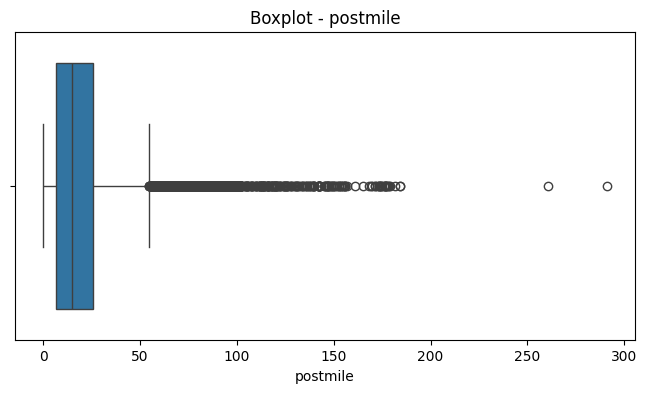

In [27]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['postmile'])
plt.title('Boxplot - postmile')
plt.show()

In [28]:
collisions_pd['postmile'].median()

15.03

In [29]:
collisions_df = collisions_df.fillna(collisions_pd['postmile'].median(), subset=['postmile'])

In [30]:
# filled na values of postmile as median value because there are extreme values that can skew the mean

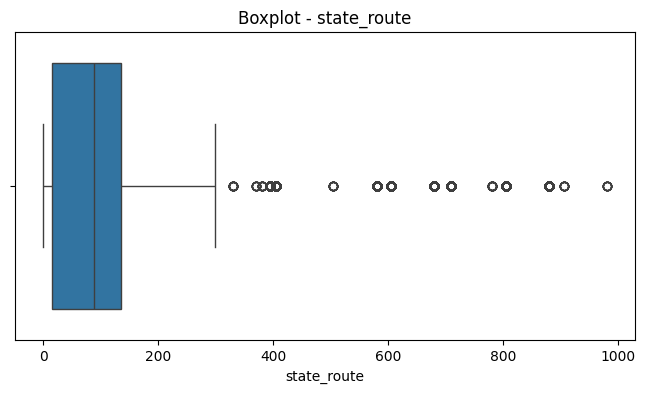

In [31]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['state_route'])
plt.title('Boxplot - state_route')
plt.show()

In [32]:
collisions_pd['state_route'].median()
collisions_df = collisions_df.fillna(collisions_pd['state_route'].median(), subset=['state_route'])

In [33]:
# filled na values of state_route as median value because there are extreme values that can skew the mean

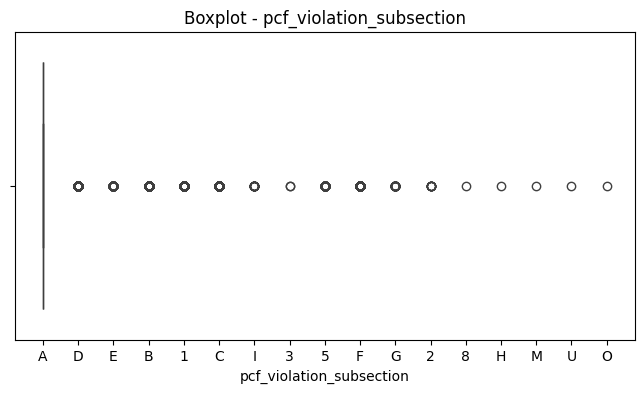

In [34]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['pcf_violation_subsection'])
plt.title('Boxplot - pcf_violation_subsection')
plt.show()

In [35]:
collisions_df = collisions_df.fillna('unknown', ['pcf_violation_subsection' , 'reporting_district'])

In [36]:
# filled pcf_violation_subsection and reporting_district as unknown as its a categorical value and mode will skew the data

/tmp/ipykernel_7643/3728441615.py:5: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


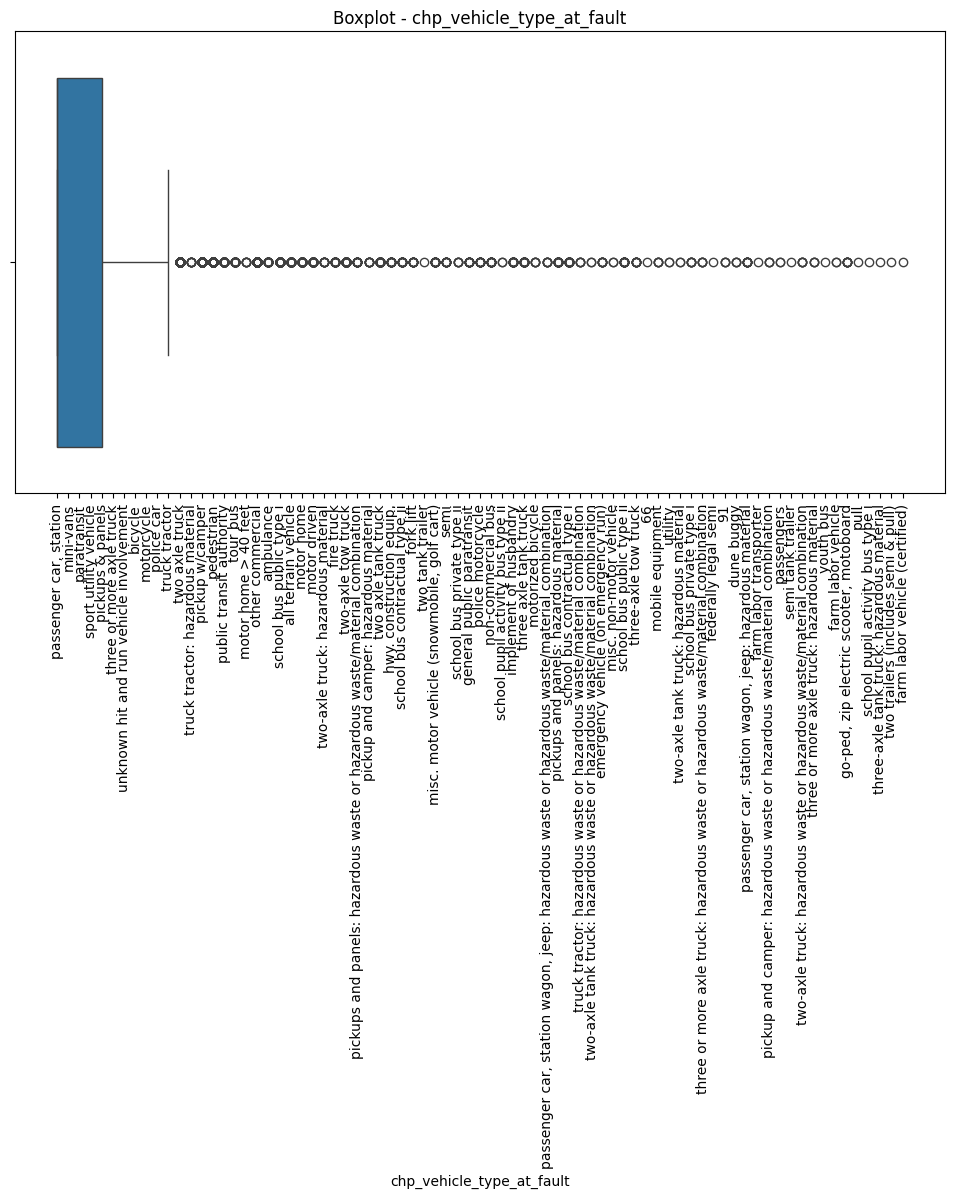

In [37]:
plt.figure(figsize=(12, 6))
sns.boxplot(x=collisions_pd['chp_vehicle_type_at_fault'])
plt.title('Boxplot - chp_vehicle_type_at_fault')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [38]:
passenger_car_counts = collisions_pd['chp_vehicle_type_at_fault'].value_counts() / len(collisions_pd) * 100
print(passenger_car_counts)

chp_vehicle_type_at_fault
passenger car, station                       43.865057
pickups & panels                             10.378314
sport utility vehicle                         9.346236
unknown hit and run vehicle involvement       3.796881
mini-vans                                     2.666919
                                               ...    
pull                                          0.000859
school pupil activity bus type i              0.000859
three-axle tank truck: hazardous material     0.000859
two trailers (includes semi & pull)           0.000859
farm labor vehicle (certified)                0.000859
Name: count, Length: 77, dtype: float64


In [39]:
collisions_pd['chp_vehicle_type_at_fault'].mode()

,chp_vehicle_type_at_fault
0,"passenger car, station"


In [40]:
# as we can clearly see that the value of passenger car, station is way more than any onher value, so we can safely fill it as na value
collisions_df = collisions_df.fillna(collisions_pd['chp_vehicle_type_at_fault'].mode()[0], subset=['chp_vehicle_type_at_fault'])

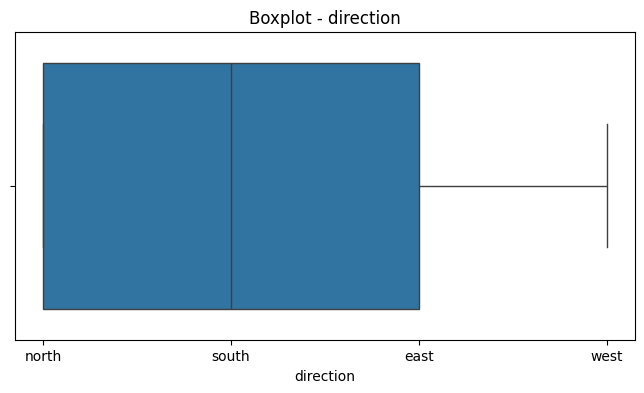

In [41]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=collisions_pd['direction'])
plt.title('Boxplot - direction')
plt.show()

In [42]:
direct_percent = collisions_pd['direction'].value_counts() / len(collisions_pd) * 100
direct_percent

,count
direction,
north,20.852796
south,20.642430
west,17.429420
east,17.255976


In [43]:
# as the values are uniformally filled, hence filling na values as unknown, to prevent the dat from skewing
collisions_df = collisions_df.fillna('unknown', subset=['direction'])

In [44]:
# filled na values as it is categorigal data and not a single value have majority weightage
collisions_df = collisions_df.fillna('unknown', subset=['statewide_vehicle_type_at_fault'])

In [45]:
beat_perc = collisions_pd['beat_number'].value_counts() / len(collisions_pd) * 100
beat_perc

,count
beat_number,
001,4.910530
002,4.866740
003,4.208167
004,2.971734
005,1.889854
...,...
2T23,0.000859
EMLA,0.000859
A23,0.000859


In [46]:
collisions_df = collisions_df.fillna('unknown', subset=['beat_number'])

In [47]:
total_count = collisions_df.count()
missing_percent = collisions_df.select([
    (sum(when(col(c).isNull(), 1).otherwise(0)) / total_count * 100).alias(c)
    for c in collisions_df.columns
]).collect()[0].asDict()
missing_percent

{'case_id': 0.0,
 'jurisdiction': 0.0,
 'officer_id': 0.0,
 'reporting_district': 0.0,
 'chp_shift': 0.0,
 'population': 0.0,
 'county_city_location': 0.0,
 'county_location': 0.0,
 'special_condition': 0.0,
 'beat_type': 0.0,
 'chp_beat_type': 0.0,
 'chp_beat_class': 0.0,
 'beat_number': 0.0,
 'primary_road': 0.0,
 'secondary_road': 0.0,
 'distance': 0.0,
 'direction': 0.0,
 'intersection': 0.0,
 'weather_1': 0.0,
 'state_highway_indicator': 0.0,
 'caltrans_county': 0.0,
 'caltrans_district': 0.0,
 'state_route': 0.0,
 'postmile': 0.0,
 'location_type': 0.0,
 'side_of_highway': 0.0,
 'tow_away': 0.0,
 'collision_severity': 0.0,
 'killed_victims': 0.0,
 'injured_victims': 0.0,
 'party_count': 0.0,
 'primary_collision_factor': 0.0,
 'pcf_violation_category': 0.0,
 'pcf_violation': 0.0,
 'pcf_violation_subsection': 0.0,
 'hit_and_run': 0.0,
 'type_of_collision': 0.0,
 'motor_vehicle_involved_with': 0.0,
 'pedestrian_action': 0.0,
 'road_surface': 0.0,
 'road_condition_1': 0.0,
 'lighting

In [48]:
missing_prop_parties = parties_pd.isnull().mean()*100
missing_prop_parties[missing_prop_parties > 0].sort_values(ascending=False)

,0
chp_vehicle_type_towed,48.056852
party_safety_equipment_2,33.490416
cellphone_in_use,26.166367
party_race,20.456030
chp_vehicle_type_towing,18.914817
cellphone_use_type,18.672621
party_safety_equipment_1,13.053506
party_age,12.550790
party_sex,10.409264
statewide_vehicle_type,9.680683


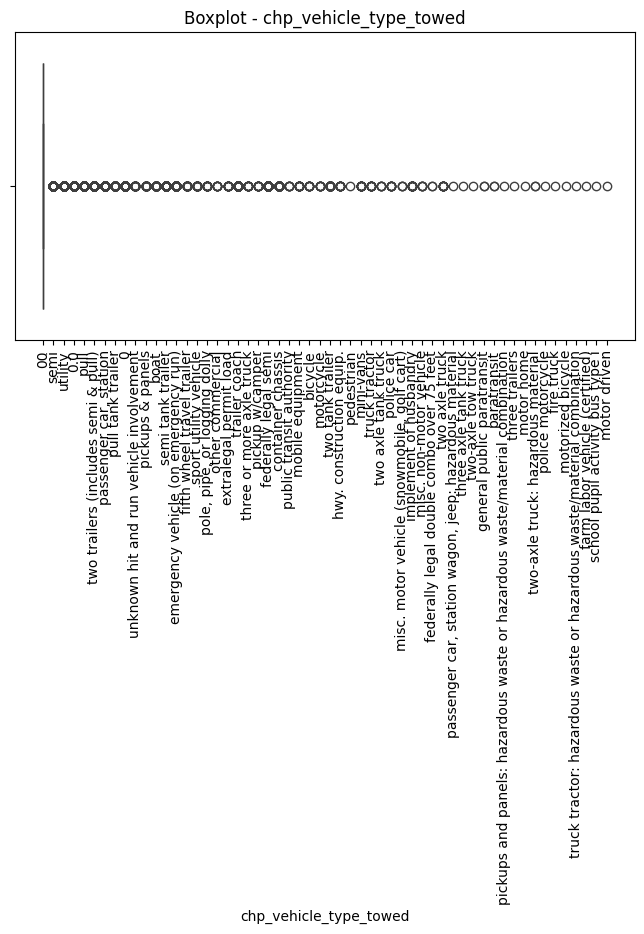

In [49]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['chp_vehicle_type_towed'])
plt.title('Boxplot - chp_vehicle_type_towed')
plt.xticks(rotation=90)
plt.show()

In [50]:
parties_df = parties_df.fillna('unknown', subset=['chp_vehicle_type_towed'])

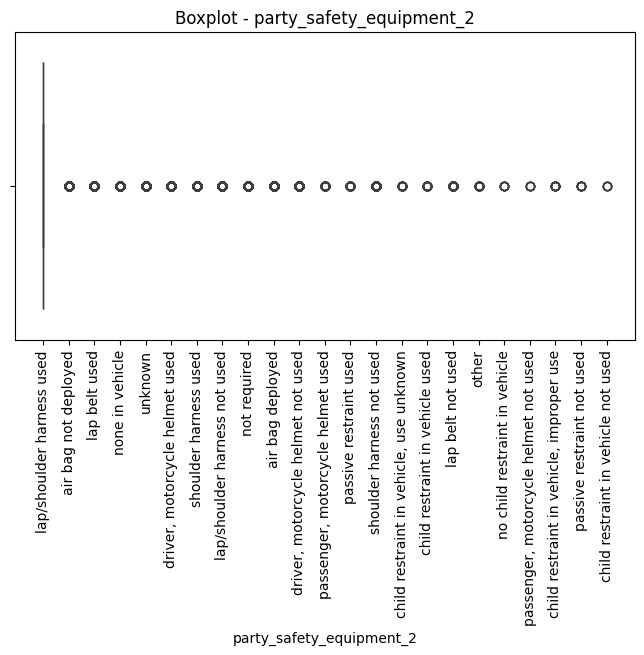

In [51]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['party_safety_equipment_2'])
plt.title('Boxplot - party_safety_equipment_2')
plt.xticks(rotation=90)
plt.show()

In [52]:
parties_df = parties_df.fillna('unknown', subset=['party_safety_equipment_2'])

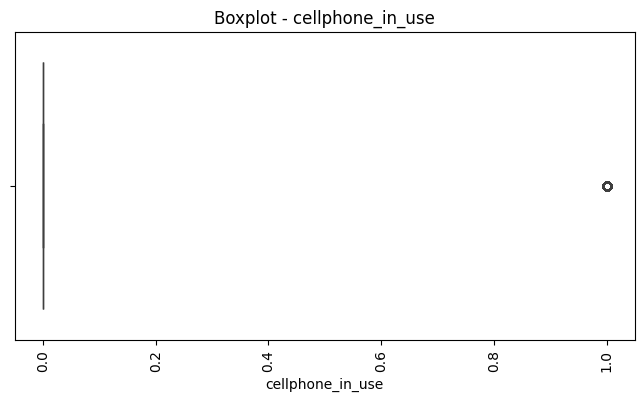

In [53]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['cellphone_in_use'])
plt.title('Boxplot - cellphone_in_use')
plt.xticks(rotation=90)
plt.show()

In [54]:
parties_pd['cellphone_in_use'].value_counts() / len(parties_pd) * 100

,count
cellphone_in_use,
0.0,72.353766
1.0,1.479867


In [55]:
parties_df = parties_df.fillna(-1, subset=['cellphone_in_use'])
# setting na values as -1 as making it 0 or 1 would have skewed the data

In [56]:
parties_df = parties_df.fillna('unknown', subset=['party_race'])

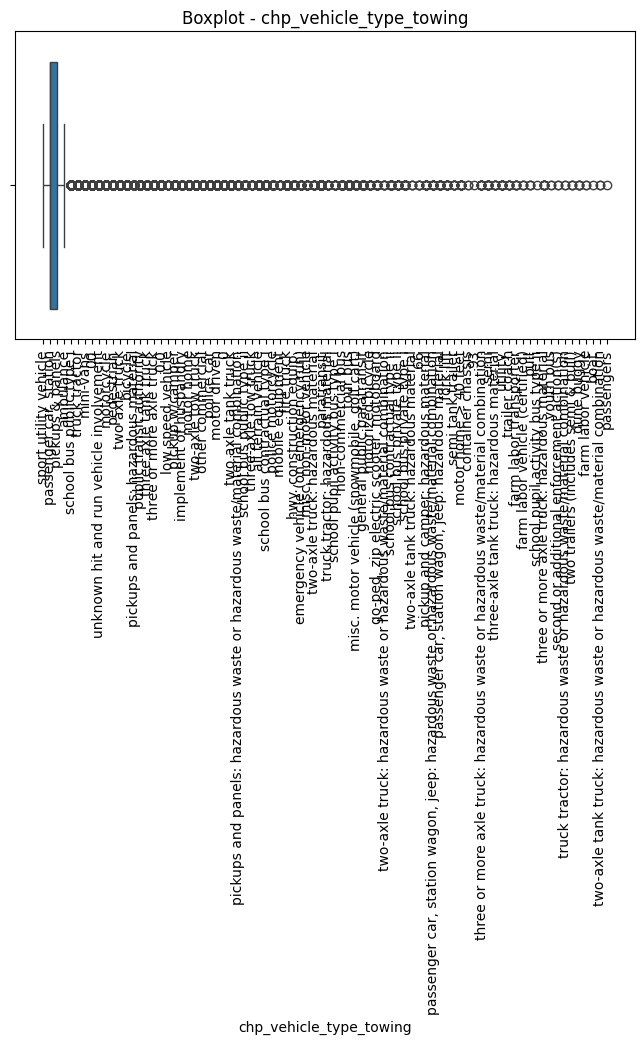

In [86]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['chp_vehicle_type_towing'])
plt.title('Boxplot - chp_vehicle_type_towing')
plt.xticks(rotation=90)
plt.show()

In [87]:
parties_df = parties_df.fillna('unknown', subset=['chp_vehicle_type_towing'])

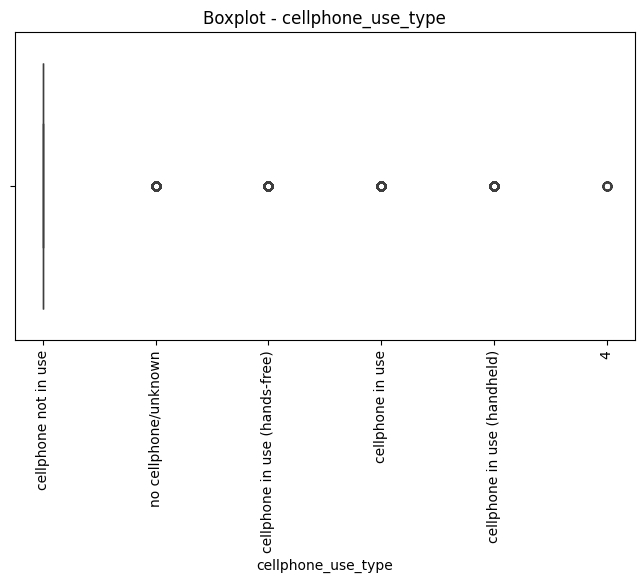

In [88]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['cellphone_use_type'])
plt.title('Boxplot - cellphone_use_type')
plt.xticks(rotation=90)
plt.show()

In [90]:
parties_pd['cellphone_use_type'].value_counts() / len(parties_pd) * 100

,count
cellphone_use_type,
cellphone not in use,72.353766
no cellphone/unknown,7.479007
cellphone in use (hands-free),0.786341
cellphone in use (handheld),0.465272
cellphone in use,0.228254
4,0.014739


In [91]:
parties_df = parties_df.fillna('unknown', subset=['cellphone_use_type'])

In [92]:
parties_pd['party_safety_equipment_1'].value_counts() / len(parties_pd) * 100

,count
party_safety_equipment_1,
air bag not deployed,47.966825
lap/shoulder harness used,17.450087
air bag deployed,11.573240
not required,4.360331
unknown,3.476394
other,0.762440
none in vehicle,0.315891
lap belt used,0.260520
"driver, motorcycle helmet used",0.244985


In [93]:
parties_df = parties_df.fillna('unknown', subset=['party_safety_equipment_1'])

In [95]:
parties_pd['party_age'].value_counts() / len(parties_pd) * 100

,count
party_age,
19.0,2.719132
20.0,2.658981
22.0,2.643047
21.0,2.586482
23.0,2.499243
...,...
101.0,0.001593
104.0,0.000398
121.0,0.000398


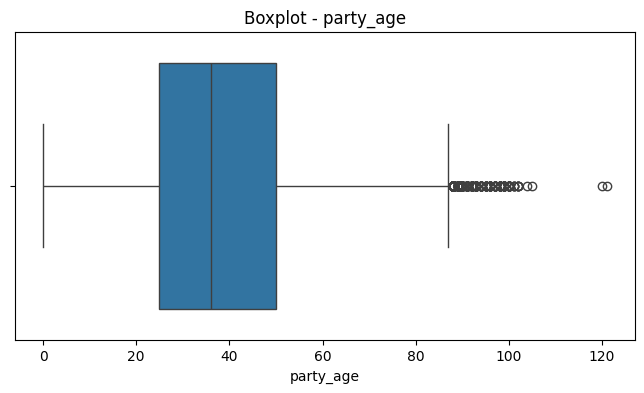

In [96]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['party_age'])
plt.title('Boxplot - party_age')
plt.show()

In [99]:
parties_pd['party_age'].median()

36.0

In [100]:
parties_df = parties_df.fillna(parties_pd['party_age'].median(), subset=['party_age'])

In [101]:
parties_pd['party_sex'].value_counts() / len(parties_pd) * 100

,count
party_sex,
male,54.946303
female,34.620931
X,0.023503


In [102]:
parties_df = parties_df.fillna('unknown', subset=['party_sex'])

In [103]:
parties_pd['statewide_vehicle_type'].value_counts() / len(parties_pd) * 100

,count
statewide_vehicle_type,
passenger car,68.511688
pickup or panel truck,12.333291
truck or truck tractor with trailer,2.046320
motorcycle or scooter,1.594592
bicycle,1.369126
truck or truck tractor,1.315748
pedestrian,0.730174
emergency vehicle,0.625010
pickup or panel truck with trailer,0.522634


In [104]:
parties_df = parties_df.fillna('unknown', subset=['statewide_vehicle_type'])

In [105]:
parties_pd['vehicle_make'].value_counts() / len(parties_pd) * 100

,count
vehicle_make,
toyota,15.008206
ford,13.111267
honda,10.923533
chevrolet,9.345672
nissan,6.004716
...,...
YAHAHA,0.000398
SOUTHWIND,0.000398
SCHWINN=,0.000398


In [106]:
parties_df = parties_df.fillna('unknown', subset=['vehicle_make'])

In [107]:
parties_pd['vehicle_year'].value_counts() / len(parties_pd) * 100

,count
vehicle_year,
2000.0,5.485269
2001.0,5.376918
2002.0,4.925987
2003.0,4.714065
2004.0,4.439204
...,...
1953.0,0.000398
1021.0,0.000398
1939.0,0.000398


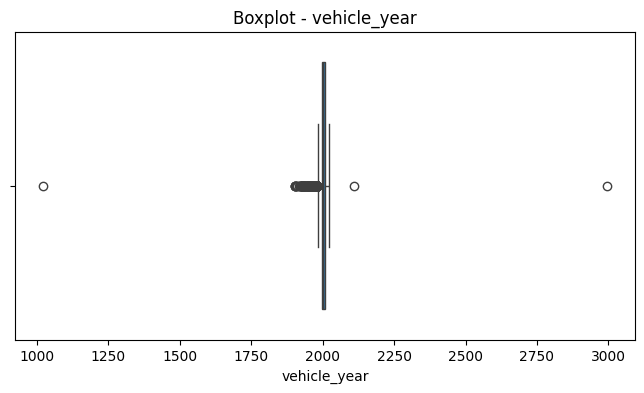

In [108]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=parties_pd['vehicle_year'])
plt.title('Boxplot - vehicle_year')
plt.show()

In [110]:
parties_pd['vehicle_year'].median()

np.float64(2001.7455835117773)

In [111]:
parties_df = parties_df.fillna(parties_pd['vehicle_year'].median(), subset=['vehicle_year'])

In [112]:
parties_pd['financial_responsibility'].value_counts() / len(parties_pd) * 100

,count
financial_responsibility,
proof of insurance obtained,76.965455
no proof of insurance obtained,8.953696
not applicable,6.754011
officer called away before obtained,0.005975


In [113]:
parties_df = parties_df.fillna('unknown', subset=['financial_responsibility'])

**victims_df**

In [114]:
missing_prop_victims = victims_pd.isnull().mean()*100
missing_prop_victims[missing_prop_victims > 0].sort_values(ascending=False)

,0
victim_safety_equipment_2,29.157165


In [115]:
victims_pd['victim_safety_equipment_2'].value_counts() / len(victims_pd) * 100

,count
victim_safety_equipment_2,
lap/shoulder harness used,57.697678
child restraint in vehicle used,4.295621
"driver, motorcycle helmet used",2.196677
lap/shoulder harness not used,1.241060
lap belt used,1.012240
unknown,0.977335
"driver, motorcycle helmet not used",0.692667
none in vehicle,0.613549
not required,0.373094


In [116]:
victims_df = victims_df.fillna('unknown', subset=['victim_safety_equipment_2'])

In [117]:
# update the pandas dataframe
collisions_pd = collisions_df.sample(0.15, seed=42).toPandas()
parties_pd = parties_df.sample(0.15, seed=42).toPandas()
victims_pd = victims_df.sample(0.15, seed=42).toPandas()

In [120]:
(collisions_pd.isnull().mean()*100).sort_values(ascending=False)

,0
case_id,0.0
jurisdiction,0.0
officer_id,0.0
reporting_district,0.0
chp_shift,0.0
...,...
latitude,0.0
longitude,0.0
collision_date,0.0
collision_time,0.0


In [121]:
(parties_pd.isnull().mean()*100).sort_values(ascending=False)

,0
id,0.0
case_id,0.0
party_number,0.0
party_type,0.0
at_fault,0.0
party_sex,0.0
party_age,0.0
party_sobriety,0.0
direction_of_travel,0.0
party_safety_equipment_1,0.0


In [122]:
(victims_pd.isnull().mean()*100).sort_values(ascending=False)

,0
id,0.0
case_id,0.0
party_number,0.0
victim_role,0.0
victim_sex,0.0
victim_age,0.0
victim_degree_of_injury,0.0
victim_seating_position,0.0
victim_safety_equipment_1,0.0
victim_safety_equipment_2,0.0


##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [123]:
#Remove Duplicates
collisions_df = collisions_df.dropDuplicates()
parties_df = parties_df.dropDuplicates()
victims_df = victims_df.dropDuplicates()

In [59]:
#Detect Outliers using IQR


# List of numerical columns to check for outliers


##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [60]:
#Remove Outliers



#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [61]:
# Encode Categorical Variables

# String Indexing for Categorical Columns


In [62]:
# Reordering & Renaming Columns


In [63]:
# Final cleaned data


Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

In [64]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas

# Plot


##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

In [65]:
# Weather Conditions During Collisions

# Convert to Pandas

# Plot


##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

In [66]:
# Distribution of Victim Ages

# Convert to Pandas

# Plot


##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

In [67]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Convert to Pandas

# Plot


##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

In [68]:
# Weather vs. Collision Severity

# Convert to Pandas

# Plot


##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

In [69]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas

# Plot


##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

In [70]:
# Extract the weekday

# Plot


##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

In [71]:
# Spatial Analysis

# Collision Density by County

# Plot the map


##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

In [72]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values

# Convert to numeric (if needed) and handle invalid data

# Plot the scatter plot


##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [73]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date

# Plot


Q: Analyze yearly, monthly and hourly trends in collisions.

In [74]:
# Yearly Trend of Collisions

# Plot


In [75]:
# Monthly Trend of Collisions

# Plot


In [76]:
# Hourly Trend of Collisions

# Plot


#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

##**4.1 Loading the Dataset** <font color = red>[1 marks]</font> <br>

Q: Load the processed dataset as CSV files in S3 bucket.

In [77]:
# Write your query here

## **4.2. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [78]:
# Query: Identify the top 5 counties with the most collisions


##**4.3. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [79]:
# Query: Find the month with the highest number of collisions


##**4.4. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [80]:
# Query: Find the most common weather condition during collisions


##**4.5. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [81]:
# Query: Determine the percentage of collisions that resulted in fatalities


##**4.6. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [82]:
# Query: Find the most dangerous time of day for collisions


##**4.7. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [83]:
# Query: List the top 5 road types with the highest collision frequency


##**4.8. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [84]:
# Query: Find the top 3 lighting conditions that lead to the most collisions


#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

In [85]:
# Final insights and recommendations

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>